# Módulo 2: Cuota Parte (Quota Share)

## ¿Qué es?

La aseguradora cede un porcentaje fijo $\alpha$ de **cada siniestro** al reasegurador,
independientemente de su tamaño.

$$S^{\text{retenido}} = (1-\alpha) \cdot S$$
$$S^{\text{cedido}} = \alpha \cdot S$$

Usamos $\alpha = 0.40$, la aseguradora retiene el 60% y cede el 40%.

In [29]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulation import simulate_aggregate_losses
from src.treaties import apply_quota_share

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Cargar datos simulados
df = pd.read_csv("../data/simulated_losses.csv")
S_pareto    = df["S_pareto"].values
S_lognormal = df["S_lognormal"].values

print(f"Escenarios cargados: {len(S_pareto):,}")
print(f"Media Pareto    : {S_pareto.mean():,.2f}")
print(f"Media Lognormal : {S_lognormal.mean():,.2f}")

Escenarios cargados: 100,000
Media Pareto    : 149,069.14
Media Lognormal : 458,928.03


## Aplicando la Cuota Parte

Aplicamos $\alpha = 0.40$ sobre las pérdidas brutas.
La aseguradora retiene el 60% de cada pérdida agregada.

In [30]:
# Aplicar Cuota Parte con alpha = 0.40
resultado_pareto    = apply_quota_share(S_pareto,    alpha=0.40)
resultado_lognormal = apply_quota_share(S_lognormal, alpha=0.40)

# Extraer pérdidas retenidas
ret_pareto    = resultado_pareto["retained"]
ret_lognormal = resultado_lognormal["retained"]

# Comparar métricas brutas vs retenidas
print("=" * 55)
print(f"{'Métrica':<20} {'Bruto':>15} {'Retenido (QS)':>15}")
print("=" * 55)
print(f"{'Media':<20} {S_pareto.mean():>15,.2f} {ret_pareto.mean():>15,.2f}")
print(f"{'Desv. estándar':<20} {S_pareto.std():>15,.2f} {ret_pareto.std():>15,.2f}")
print(f"{'VaR 99%':<20} {np.percentile(S_pareto,99):>15,.2f} {np.percentile(ret_pareto,99):>15,.2f}")
print(f"{'Máximo':<20} {S_pareto.max():>15,.2f} {ret_pareto.max():>15,.2f}")
print("=" * 55)

Métrica                        Bruto   Retenido (QS)
Media                     149,069.14       89,441.49
Desv. estándar            204,664.09      122,798.45
VaR 99%                   437,966.07      262,779.64
Máximo                 40,184,892.30   24,110,935.38


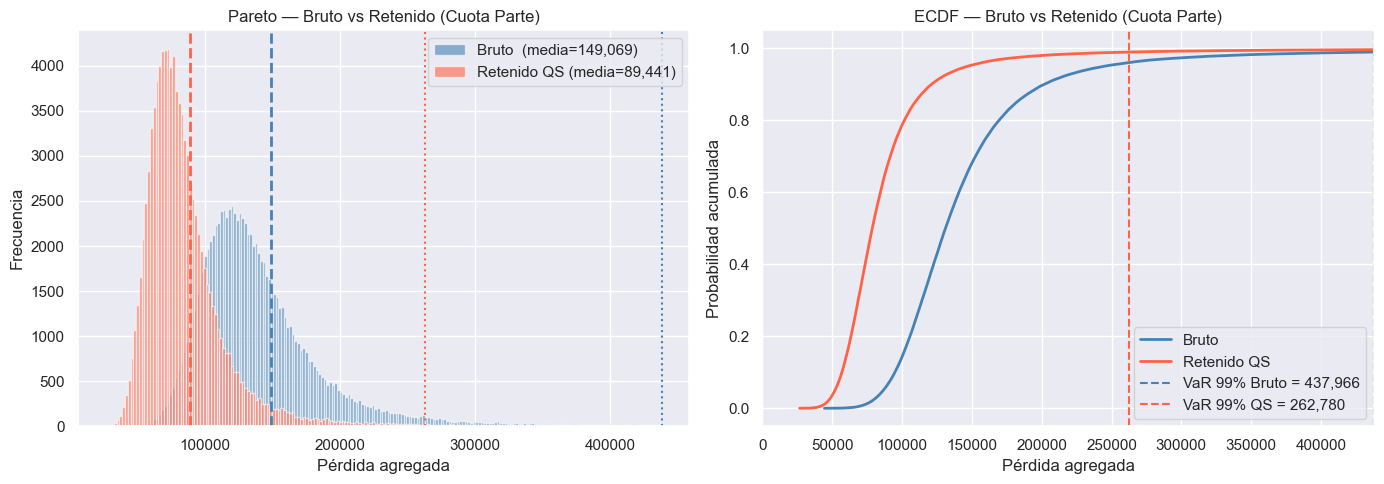

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_bruto    = np.percentile(S_pareto, 99)
p99_retenido = np.percentile(ret_pareto, 99)
x_max = p99_bruto

#  Gráfica 1: Bruto vs Retenido
axes[0].hist(S_pareto[S_pareto <= x_max], bins=200, alpha=0.6,
             color="steelblue", label=f"Bruto  (media={S_pareto.mean():,.0f})")
axes[0].hist(ret_pareto[ret_pareto <= x_max], bins=200, alpha=0.6,
             color="tomato", label=f"Retenido QS (media={ret_pareto.mean():,.0f})")
axes[0].axvline(S_pareto.mean(), color="steelblue", linewidth=2, linestyle="--")
axes[0].axvline(ret_pareto.mean(), color="tomato", linewidth=2, linestyle="--")
axes[0].axvline(p99_bruto, color="steelblue", linewidth=1.5, linestyle=":")
axes[0].axvline(p99_retenido, color="tomato", linewidth=1.5, linestyle=":")
axes[0].set_title("Pareto — Bruto vs Retenido (Cuota Parte)")
axes[0].set_xlabel("Pérdida agregada")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

#  Gráfica 2: ECDF 
S_sorted     = np.sort(S_pareto)
ret_sorted   = np.sort(ret_pareto)
probabilidad = np.arange(1, len(S_sorted) + 1) / len(S_sorted)

axes[1].plot(S_sorted,   probabilidad, color="steelblue", linewidth=2, label="Bruto")
axes[1].plot(ret_sorted, probabilidad, color="tomato",    linewidth=2, label="Retenido QS")
axes[1].axvline(p99_bruto,    color="steelblue", linewidth=1.5, linestyle="--",
                label=f"VaR 99% Bruto = {p99_bruto:,.0f}")
axes[1].axvline(p99_retenido, color="tomato",    linewidth=1.5, linestyle="--",
                label=f"VaR 99% QS = {p99_retenido:,.0f}")
axes[1].set_xlim(0, x_max)
axes[1].set_title("ECDF — Bruto vs Retenido (Cuota Parte)")
axes[1].set_xlabel("Pérdida agregada")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/03_quota_share_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen de métricas  Cuota Parte

Comparamos las métricas actuariales del portafolio bruto
contra el retenido bajo Cuota Parte con $\alpha = 0.40$.

In [ ]:
def resumen_metricas(S, nombre):
    var99  = np.percentile(S, 99)
    cvar99 = S[S > var99].mean()
    media  = S.mean()
    std    = S.std()
    prima  = media + 1.5 * std
    return {
        "Tratado"        : nombre,
        "Media"          : media,
        "Desv. Estándar" : std,
        "VaR 99%"        : var99,
        "CVaR 99%"       : cvar99,
        "Prima Técnica"  : prima,
    }

metricas = pd.DataFrame([
    resumen_metricas(S_pareto,   "Bruto"),
    resumen_metricas(ret_pareto, "Quota Share"),
])

metricas.set_index("Tratado", inplace=True)
print(metricas.map(lambda x: f"{x:,.2f}"))

                  Media Desv. Estándar     VaR 99%    CVaR 99% Prima Técnica
Tratado                                                                     
Bruto        149,069.14     204,664.09  437,966.07  943,990.34    456,065.27
Quota Share   89,441.49     122,798.45  262,779.64  566,394.20    273,639.16
